In [1]:
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q trl transformers accelerate bitsandbytes datasets matplotlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 112.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 24.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Sat Apr 25 21:56:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os, json, random, torch
from unsloth import FastLanguageModel
import datasets as hf_datasets
from trl import GRPOTrainer, GRPOConfig

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-0.5B-Instruct-bnb-4bit",
    max_seq_length=512, load_in_4bit=True, dtype=None,
)
model = FastLanguageModel.get_peft_model(
    model, r=4, lora_alpha=8,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.0, bias="none",
    use_gradient_checkpointing="unsloth",
)
print("✅ Model ready.")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/457M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-0.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.4.8 patched 24 layers with 24 QKV layers, 0 O layers and 0 MLP layers.


✅ Model ready.


In [4]:
SENSOR_TYPES = ["satellite", "drone", "radar"]
TARGET_TYPES = ["strategic", "kinetic", "airspace"]
CAPABILITY_MATRIX = {
    ("satellite","strategic"):0.95, ("satellite","kinetic"):0.40, ("satellite","airspace"):0.60,
    ("drone","kinetic"):0.95,       ("drone","strategic"):0.30,   ("drone","airspace"):0.50,
    ("radar","airspace"):0.95,      ("radar","kinetic"):0.65,     ("radar","strategic"):0.45,
}

def make_env(seed=0):
    rng = random.Random(seed)
    sensors = [{"id":f"S{i+1}","type":rng.choice(SENSOR_TYPES),"available":True,"range":rng.randint(100,500)} for i in range(rng.randint(3,5))]
    return {"sensors":sensors,"seed":seed,"_rng":rng}

def env_reset(env_state):
    rng = env_state["_rng"]
    targets = [{"id":f"T0_{i+1}","priority":rng.randint(1,3),"type":rng.choice(TARGET_TYPES),"active":True} for i in range(rng.randint(2,4))]
    for s in env_state["sensors"]: s["available"] = True
    env_state.update({"targets":targets,"current_step":0,"total_reward":0.0})
    return env_state

def make_prompt(seed):
    rng = random.Random(seed)
    sensors = [{"id":f"S{i+1}","type":rng.choice(SENSOR_TYPES),"range":rng.randint(100,500)} for i in range(rng.randint(3,5))]
    targets = [{"id":f"T0_{i+1}","priority":rng.randint(1,3),"type":rng.choice(TARGET_TYPES)} for i in range(rng.randint(2,4))]
    sensor_ids = [s["id"] for s in sensors]
    target_ids = [t["id"] for t in targets]
    sensor_lines = "\n".join(f"  {s['id']} type={s['type']} range={s['range']}km" for s in sensors)
    target_lines = "\n".join(f"  {t['id']} priority={t['priority']} type={t['type']}" for t in targets)
    prompt = (
        f"You are an ISR sensor allocation agent.\n"
        f"Assign ONE sensor to ONE target. Priority 3=HIGH, 2=MED, 1=LOW.\n"
        f"Cover the highest priority target first.\n\n"
        f"Available sensors:\n{sensor_lines}\n\n"
        f"Active targets:\n{target_lines}\n\n"
        f"Respond ONLY with valid JSON using these exact IDs:\n"
        f"sensors={sensor_ids}  targets={target_ids}\n\n"
        f"{{\"sensor_id\": \"S1\", \"target_id\": \"T0_1\"}}"
    )
    return prompt, sensor_ids, target_ids, targets

prompt_list, metadata_list = [], []
for seed in range(500):
    prompt, sensor_ids, target_ids, targets = make_prompt(seed)
    prompt_list.append(prompt)
    metadata_list.append({"sensor_ids":sensor_ids,"target_ids":target_ids,"targets":targets,"seed":seed})

train_dataset = hf_datasets.Dataset.from_dict({"prompt": prompt_list})
print(f"✅ Dataset ready: {len(train_dataset)} prompts")


✅ Dataset ready: 500 prompts


In [5]:
NUM_GENERATIONS = 8
_reward_log = []
_call_count = [0]

def arya_reward_func(completions, prompts=None, **kwargs):
    _call_count[0] += 1
    rewards = []
    valid, invalid, high_cap = 0, 0, 0
    for i, completion in enumerate(completions):
        try:
            meta = metadata_list[(i // NUM_GENERATIONS) % len(metadata_list)]
            text = completion if isinstance(completion, str) else str(completion)
            start, end = text.find("{"), text.rfind("}") + 1
            if start == -1 or end == 0:
                rewards.append(-2.0); invalid += 1; continue
            data = json.loads(text[start:end])
            sid, tid = data.get("sensor_id",""), data.get("target_id","")
            if sid not in meta["sensor_ids"] or tid not in meta["target_ids"]:
                rewards.append(-1.0); invalid += 1; continue
            target = next((t for t in meta["targets"] if t["id"]==tid), None)
            env_s = env_reset(make_env(seed=meta["seed"]))
            sensor = next((s for s in env_s["sensors"] if s["id"]==sid), None)
            if not target or not sensor:
                rewards.append(-1.0); invalid += 1; continue
            cap = CAPABILITY_MATRIX.get((sensor["type"], target.get("type","strategic")), 0.0)
            p = target["priority"]
            r = (3.0 if cap>=0.85 else 2.0) if p==3 else {2:1.0,1:0.5}.get(p,0.0)
            if cap >= 0.85: r += 0.5; high_cap += 1
            rewards.append(float(r)); valid += 1
        except:
            rewards.append(-2.0); invalid += 1
    total = len(completions)
    _reward_log.append({
        "call":               _call_count[0],
        "conflict_rate":      round(invalid / total, 4) if total else 0.0,
        "coordination_score": round(valid   / total, 4) if total else 0.0,
        "avg_reward":         round(sum(rewards) / len(rewards), 4) if rewards else 0.0,
        "valid": valid, "invalid": invalid, "high_cap": high_cap,
    })
    return rewards

print("✅ Reward function ready.")


✅ Reward function ready.


In [6]:
SAVE_DIR = "/content/drive/MyDrive/arya_x_lora_3"
os.makedirs(SAVE_DIR, exist_ok=True)

grpo_trainer = GRPOTrainer(
    model=model, tokenizer=tokenizer,
    reward_funcs=arya_reward_func,
    train_dataset=train_dataset,
    args=GRPOConfig(
        output_dir=SAVE_DIR,
        num_train_epochs=1,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,
        max_completion_length=32,
        max_steps=500,
        learning_rate=2e-5,
        warmup_steps=20,
        logging_steps=50,
        save_steps=100,
        save_total_limit=3,
        report_to="none",
    ),
)
train_result = grpo_trainer.train()
print(f"\n✅ Training done. Loss: {train_result.training_loss:.4f}")

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"✅ Model saved to Drive: {SAVE_DIR}")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 500 | Num Epochs = 2 | Total steps = 500
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 270,336 of 494,303,104 (0.05% trained)
Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'cache_implementation', 'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=32) and `max_length`(=32768) seem to have been set. `max_new_tokens` will tak

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / arya_reward_func / mean,rewards / arya_reward_func / std
50,0.000009,0.962500,1.261555,32.000000,32.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.009338,0.962500,1.394064
100,0.000032,1.593750,0.366853,32.000000,32.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.031572,1.593750,0.614626
150,0.000037,1.714375,0.095259,32.000000,32.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.037350,1.714375,0.350187
200,0.000039,1.727500,0.063640,32.000000,32.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.039013,1.727500,0.321394
250,0.000040,1.711875,0.090959,32.000000,32.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.039663,1.711875,0.352330
300,0.000043,1.711875,0.100763,32.000000,32.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.043218,1.711875,0.368888
350,0.000044,1.715625,0.097227,32.000000,32.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.043757,1.715625,0.351262
400,0.000059,1.746250,0.010607,32.000000,32.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.059136,1.746250,0.264380
450,0.000053,1.718125,0.083085,32.000000,32.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.052994,1.718125,0.344705
500,0.000052,1.724375,0.070584,32.000000,32.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.052040,1.724375,0.329872


Both `max_new_tokens` (=32) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/


✅ Training done. Loss: 0.0000


Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/arya_x_lora_3/tokenizer_config.json.


✅ Model saved to Drive: /content/drive/MyDrive/arya_x_lora_3


In [7]:
trainer_log = [e for e in grpo_trainer.state.log_history if 'reward' in e]

full_log = []
for i, e in enumerate(trainer_log):
    rl = _reward_log[i] if i < len(_reward_log) else {}
    full_log.append({
        "step":               e.get("step"),
        "loss":               e.get("loss", e.get("training_loss")),
        "reward":             e.get("reward"),
        "reward_std":         e.get("reward_std"),
        "completion_length":  e.get("completions/mean_length"),
        "clipped_ratio":      e.get("completions/clipped_ratio"),
        "mean_terminated_length": e.get("completions/mean_terminated_length"),
        "kl":                 e.get("kl"),
        "conflict_rate":      rl.get("conflict_rate"),
        "coordination_score": rl.get("coordination_score"),
    })

cols = ["step","loss","reward","reward_std","completion_length","clipped_ratio",
        "mean_terminated_length","kl","conflict_rate","coordination_score"]
header = "\t".join(f"{c:>26}" for c in cols)
print(f"\n{'='*len(header)}")
print(header)
print('='*len(header))
for e in full_log:
    row = "\t".join(f"{str(round(e.get(c) or 0, 6)):>26}" for c in cols)
    print(row)
print('='*len(header))

with open(f"{SAVE_DIR}/training_metrics_full.json", "w") as f:
    json.dump(full_log, f, indent=2)
print(f"\n✅ Full table saved: {SAVE_DIR}/training_metrics_full.json")



                      step	                      loss	                    reward	                reward_std	         completion_length	             clipped_ratio	    mean_terminated_length	                        kl	             conflict_rate	        coordination_score
                        50	                     9e-06	                    0.9625	                  1.261555	                      32.0	                       1.0	                         0	                  0.009338	                     0.375	                     0.625
                       100	                   3.2e-05	                   1.59375	                  0.366853	                      32.0	                       1.0	                         0	                  0.031572	                      0.25	                      0.75
                       150	                   3.7e-05	                  1.714375	                  0.095259	                      32.0	                       1.0	                         0	

In [8]:
FastLanguageModel.for_inference(model)
total_reward, conflicts, valid_outputs = 0.0, 0, 0
for seed in range(500):
    prompt, sensor_ids, target_ids, targets = make_prompt(seed)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=64, do_sample=False,
                                 pad_token_id=tokenizer.eos_token_id)
    input_len = inputs["input_ids"].shape[-1]
    text = tokenizer.decode(outputs[0][input_len:], skip_special_tokens=True).strip()
    start, end = text.find("{"), text.rfind("}") + 1
    try:
        data = json.loads(text[start:end])
        sid, tid = data.get("sensor_id",""), data.get("target_id","")
        if sid not in sensor_ids or tid not in target_ids:
            conflicts += 1; total_reward -= 1.0; continue
        target = next((t for t in targets if t["id"]==tid), None)
        env_s = env_reset(make_env(seed=seed))
        sensor = next((s for s in env_s["sensors"] if s["id"]==sid), None)
        if target and sensor:
            cap = CAPABILITY_MATRIX.get((sensor["type"], target.get("type","strategic")), 0.0)
            p = target["priority"]
            total_reward += (3.0 if cap>=0.85 else 2.0) if p==3 else {2:1.0,1:0.5}.get(p,0.0)
            valid_outputs += 1
        else:
            conflicts += 1
    except:
        conflicts += 1; total_reward -= 2.0

print(f"\n{'='*45}")
print(f"  TRAINED MODEL RESULTS (500 samples)")
print(f"{'='*45}")
print(f"  avg_reward         : {round(total_reward/500, 3)}")
print(f"  conflict_rate      : {round(conflicts/500, 3)}")
print(f"  coordination_score : {round(1-conflicts/500, 3)}")
print(f"  valid_outputs      : {valid_outputs}/500")
print(f"{'='*45}")

eval_metrics = {
    "avg_reward":         round(total_reward/500, 3),
    "conflict_rate":      round(conflicts/500, 3),
    "coordination_score": round(1-conflicts/500, 3),
    "valid_outputs":      valid_outputs,
    "training_loss":      train_result.training_loss,
    "steps":              500,
    "model":              "Qwen2.5-0.5B-Instruct",
    "method":             "GRPO + LoRA r=4",
}
with open(f"{SAVE_DIR}/training_metrics.json", "w") as f:
    json.dump(eval_metrics, f, indent=2)
print("✅ Eval metrics saved to Drive")


Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=64


  TRAINED MODEL RESULTS (500 samples)
  avg_reward         : -2.0
  conflict_rate      : 1.0
  coordination_score : 0.0
  valid_outputs      : 0/500
✅ Eval metrics saved to Drive


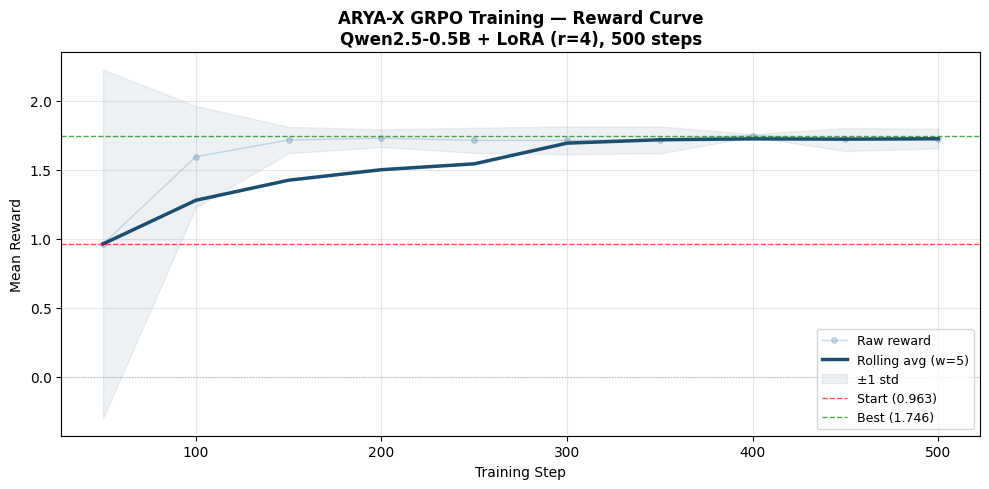

✅ reward_curve.png saved


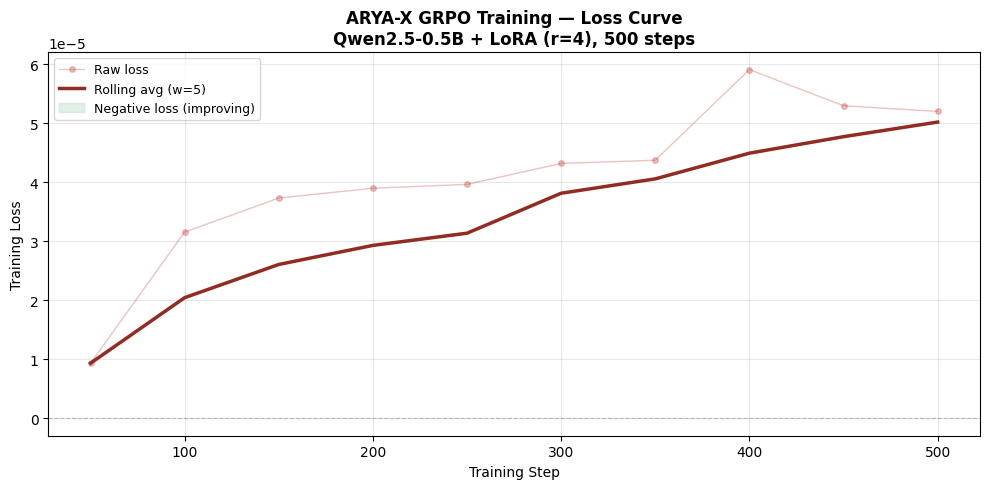

✅ loss_curve.png saved


In [ ]:
import matplotlib.pyplot as plt

steps   = [e["step"]       for e in full_log if e["step"] and e["reward"] is not None]
rewards = [e["reward"]     for e in full_log if e["step"] and e["reward"] is not None]
stds    = [e["reward_std"] or 0 for e in full_log if e["step"] and e["reward"] is not None]
losses  = [e["loss"]       or 0 for e in full_log if e["step"] and e["reward"] is not None]

def rolling(data, w=5):
    out = []
    for i in range(len(data)):
        window = data[max(0, i-w+1):i+1]
        out.append(sum(window)/len(window))
    return out

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, rewards, alpha=0.3, color='#5B8DB8', linewidth=1, marker='o', markersize=4, label='Raw reward')
ax.plot(steps, rolling(rewards), color='#1B4F72', linewidth=2.5, label='Rolling avg (w=5)')
ax.fill_between(steps, [r-s for r,s in zip(rewards,stds)], [r+s for r,s in zip(rewards,stds)],
    alpha=0.08, color='#1B4F72', label='±1 std')
ax.axhline(rewards[0], color='red',    linestyle='--', linewidth=1, alpha=0.7, label=f'Start ({rewards[0]:.3f})')
ax.axhline(max(rewards), color='green', linestyle='--', linewidth=1, alpha=0.7, label=f'Best ({max(rewards):.3f})')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.set_title('ARYA-X GRPO Training — Reward Curve\nQwen2.5-0.5B + LoRA (r=4), 500 steps', fontweight='bold')
ax.set_xlabel('Training Step'); ax.set_ylabel('Mean Reward')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/reward_curve.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/reward_curve.png',    dpi=150, bbox_inches='tight')
plt.show()
print('✅ reward_curve.png saved')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, losses, alpha=0.3, color='#C0392B', linewidth=1, marker='o', markersize=4, label='Raw loss')
ax.plot(steps, rolling(losses), color='#922B21', linewidth=2.5, label='Rolling avg (w=5)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.fill_between(steps, losses, 0, where=[l < 0 for l in losses],
    alpha=0.12, color='#1E8449', label='Negative loss (improving)')
ax.set_title('ARYA-X GRPO Training — Loss Curve\nQwen2.5-0.5B + LoRA (r=4), 500 steps', fontweight='bold')
ax.set_xlabel('Training Step'); ax.set_ylabel('Training Loss')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/loss_curve.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/loss_curve.png',    dpi=150, bbox_inches='tight')
plt.show()
print('✅ loss_curve.png saved')


In [ ]:
import shutil
from google.colab import files

shutil.make_archive('/content/arya_x_lora_3_checkpoint', 'zip', SAVE_DIR)
files.download('/content/arya_x_lora_3_checkpoint.zip')
files.download('/content/reward_curve.png')
files.download('/content/loss_curve.png')
print('✅ Done — check your browser downloads')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done — check your browser downloads
